# **Clusterização espaço-temporal e dinâmica de eventos sísmicos**

## **1. Imports**

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import sqlite3

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.pipeline import Pipeline
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import f1_score, accuracy_score

# Transforma o diretório src em um módulo importável
ROOT = Path().resolve().parent
sys.path.append(str(ROOT)) 

I0000 00:00:1773597834.620996    8282 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773597834.621468    8282 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773597834.649455    8282 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773597835.464396    8282 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [2]:
from src.data_ingestion.io_usgs         import build_catalog, save_catalog_parquet, load_catalog_parquet, USGCQuery
from src.window_features.schemas import WindowConfig
from src.window_features.builder import build_features_df
from src.pca_pipeline.prepare import prepare_X
from src.pca_pipeline.pca_utils import fit_pca_full, fit_pca, pca_loadings
from src.pca_pipeline.plots import plot_explained_variance, plot_cumulative_variance
from sklearn.cluster import KMeans
from src.clustering.plots import plot_inertia_silhouette_vs_k, plot_clusters_pca
from src.clustering.metrics import silhouette_by_cluster
from src.spatial_validation.distance import add_plate_distance_column, summarize_plate_distance_by_cluster, plot_distance_boxplot



## **2. Importação de dados sísmicos**

In [11]:
db_path = Path.cwd().parent / "data" / "seismic.db"
conn = sqlite3.connect(db_path)

df = pd.read_sql("SELECT * FROM earthquakes", conn)
df = pd.read_sql("SELECT * FROM earthquakes", conn)
df["time"] = pd.to_datetime(df["time"], format="ISO8601")
conn.close()

df.head()

,id,time,updated,mag,magType,longitude,latitude,depth,nst,gap,dmin,rms,net,place,type,status
0,us6000jkms,2023-02-01 00:21:59.374000+00:00,2023-04-13 21:53:14.040000+00:00,5.0,mb,159.7462,-9.6025,29.152,104.0,49.0,0.257,0.49,us,"10 km NNE of Malango, Solomon Islands",earthquake,reviewed
1,us6000jkna,2023-02-01 03:14:15.920000+00:00,2023-04-13 21:53:15.040000+00:00,4.8,mb,-30.6876,2.4364,10.000,53.0,47.0,14.279,0.40,us,central Mid-Atlantic Ridge,earthquake,reviewed
2,us6000jkpj,2023-02-01 09:33:46.880000+00:00,2023-04-13 21:53:15.040000+00:00,4.6,mb,103.2863,-5.2966,62.107,39.0,89.0,0.987,0.27,us,"140 km S of Pagar Alam, Indonesia",earthquake,reviewed
3,us6000jkpr,2023-02-01 10:44:46.067000+00:00,2025-08-04 14:42:43.446000+00:00,6.0,mww,126.0566,7.7431,19.000,220.0,35.0,0.820,0.67,us,"1 km NW of Babag, Philippines",earthquake,reviewed
4,us6000jkpu,2023-02-01 10:52:27.941000+00:00,2023-04-13 21:53:15.040000+00:00,4.8,mb,-78.5357,-9.8409,61.141,47.0,168.0,2.705,0.69,us,"44 km SSW of Puerto Casma, Peru",earthquake,reviewed


## **3. Extração de features por janela: coarse-graining temporal**

Os eventos sísmicos brutos são agregados em janelas temporais fixas, e cada janela é representada por um vetor de estatísticas resumidas. Esse procedimento atua como um **coarse-graining temporal**, transformando a sequência irregular de eventos em uma série pseudo-temporal de estados agregados.

In [12]:
window_cfg = WindowConfig(
    window_size=pd.Timedelta("8h"),
    step_size=pd.Timedelta("1h"),
    min_events=1
)

features_df = build_features_df(df, window_cfg)
features_df

,window_start,window_end,window_label,n_events,rate_per_day,n_earthquakes,frac_earthquake,mag_mean,mag_std,mag_min,...,unique_magType,unique_net,energy_sum_log10,dt_mean_norm,dt_std_norm,dt_p95_norm,dt_mean_s,dt_median_s,dt_std_s,dt_p95_s
0,2023-02-01 00:00:00+00:00,2023-02-01 08:00:00+00:00,2023-02-01 00:00:00+00:00,2,6.0,2,1.0,4.900,0.141,4.8,...,1,1,7.676,0.359,0.000,0.359,10336.000,10336.0,0.000,10336.00
1,2023-02-01 01:00:00+00:00,2023-02-01 09:00:00+00:00,2023-02-01 01:00:00+00:00,1,3.0,1,1.0,4.800,NaN,4.8,...,1,1,7.200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-02-01 02:00:00+00:00,2023-02-01 10:00:00+00:00,2023-02-01 02:00:00+00:00,2,6.0,2,1.0,4.700,0.141,4.6,...,1,1,7.376,0.791,0.000,0.791,22770.000,22770.0,0.000,22770.00
3,2023-02-01 03:00:00+00:00,2023-02-01 11:00:00+00:00,2023-02-01 03:00:00+00:00,5,15.0,5,1.0,4.960,0.590,4.6,...,2,1,9.020,0.239,0.323,0.694,6885.750,2360.0,9316.291,19993.35
4,2023-02-01 04:00:00+00:00,2023-02-01 12:00:00+00:00,2023-02-01 04:00:00+00:00,6,18.0,6,1.0,4.933,0.547,4.6,...,3,1,9.030,0.041,0.054,0.124,1169.600,461.0,1568.138,3578.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26387,2026-02-10 03:00:00+00:00,2026-02-10 11:00:00+00:00,2026-02-10 03:00:00+00:00,2,6.0,2,1.0,5.050,0.071,5.0,...,2,1,7.882,0.180,0.000,0.180,5192.000,5192.0,0.000,5192.00
26388,2026-02-10 04:00:00+00:00,2026-02-10 12:00:00+00:00,2026-02-10 04:00:00+00:00,2,6.0,2,1.0,5.050,0.071,5.0,...,2,1,7.882,0.180,0.000,0.180,5192.000,5192.0,0.000,5192.00
26389,2026-02-10 05:00:00+00:00,2026-02-10 13:00:00+00:00,2026-02-10 05:00:00+00:00,2,6.0,2,1.0,5.050,0.071,5.0,...,2,1,7.882,0.180,0.000,0.180,5192.000,5192.0,0.000,5192.00
26390,2026-02-10 06:00:00+00:00,2026-02-10 14:00:00+00:00,2026-02-10 06:00:00+00:00,3,9.0,3,1.0,5.033,0.058,5.0,...,2,1,8.033,0.342,0.162,0.487,9844.000,9844.0,4652.000,14030.80


## **4. Redução de dimensionalidade (PCA)**

O vetor de features agregadas por janela possui alta dimensionalidade e redundâncias internas. Aplicamos Análise de Componentes Principais (PCA) para projetar os dados em um subespaço de menor dimensão que preserva a maior parte da variância, reduzindo colinearidade e facilitando a etapa subsequente de clusterização.

In [13]:
# ------ PCA ------- #
cols_to_remove = [
    'n_earthquakes', 'frac_earthquake',
    'dt_mean_s', 'dt_std_s', 'dt_p95_s',
    'lat_mean', 'lon_mean'
]

# ---- Prepare X
X_scaled, feature_names, imputer, scaler = prepare_X(
    features_df,
    cols_to_remove=cols_to_remove,
)

# ---- PCA exploratório
pca_full = fit_pca_full(X_scaled)


<Axes: xlabel='Number of components', ylabel='Cumulative explained variance'>

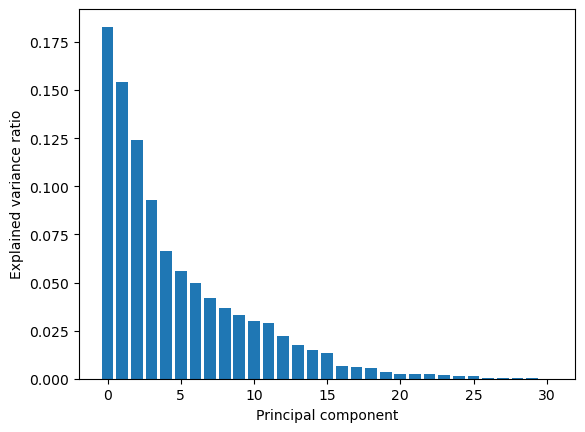

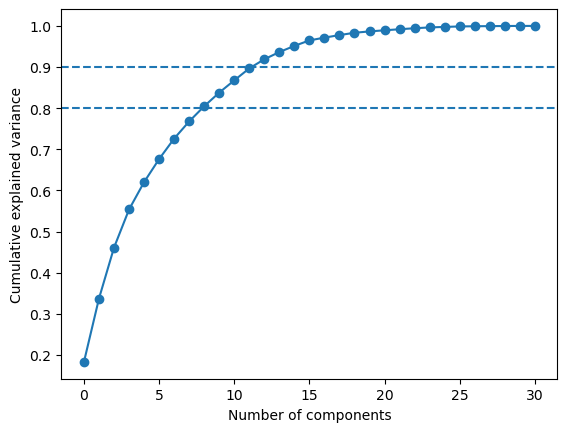

In [14]:
plot_explained_variance(pca_full)
plot_cumulative_variance(pca_full)

In [15]:
# ---- PCA final
pca, Z = fit_pca(X_scaled, n_components=11)

# ---- Loadings
loadings = pca_loadings(pca, feature_names, sort_by="PC1")
loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
energy_sum_log10,0.372019,-0.100582,-0.000490,0.062210,0.094934,-0.181519,0.048267,-0.056721,-0.053985,0.064513,-0.055630
mag_max,0.349296,-0.131602,0.029129,0.062839,0.098862,-0.206591,0.073983,-0.117611,-0.087852,0.078488,-0.060036
mag_std,0.286183,-0.152144,0.101538,0.050215,0.122110,-0.232827,0.093330,-0.319266,-0.141769,0.081648,-0.078788
mag_mean,0.276935,-0.277496,0.214987,-0.015089,0.012432,0.040491,-0.052766,-0.032043,-0.006302,0.008671,-0.014926
mag_q75,0.264843,-0.235514,0.192900,-0.021459,0.026732,0.024859,-0.047820,-0.035827,-0.011387,0.010827,-0.001119


## **5. Clusterização com KMeans**

Aplicamos o algoritmo K-Means sobre a representação reduzida via PCA para identificar regimes estatísticos recorrentes do sistema.O número de clusters $K$ é selecionado com base na análise conjunta da inércia (elbow method) e do coeficiente de silhueta, buscando um compromisso entre separação dos grupos e parcimônia do modelo.

(<Figure size 700x400 with 2 Axes>,
 (<Axes: title={'center': 'Elbow (Inertia) + Silhouette vs k'}, xlabel='k', ylabel='Inertia'>,
  <Axes: ylabel='Silhouette score'>))

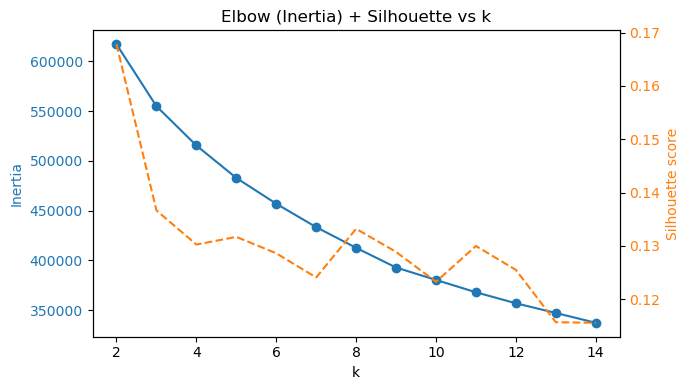

In [16]:
# ---- escolher k
plot_inertia_silhouette_vs_k(Z, ks=range(2, 15))

In [17]:
# ---- KMeans final
km = KMeans(n_clusters=2, n_init=20, random_state=42)
labels = km.fit_predict(Z)


(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Cluster centroids in PCA space'}, xlabel='PC1', ylabel='PC2'>)

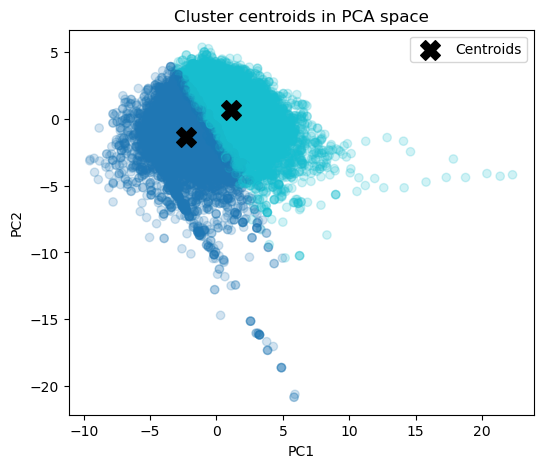

In [18]:
# ---- scatter PC1 vs PC2
plot_clusters_pca(Z, labels)

In [19]:
sil_stats = silhouette_by_cluster(Z, labels)
sil_stats

,mean,median,std,count
cluster,,,,
0,0.068207,0.059000,0.092232,8589
1,0.215886,0.218059,0.076480,17803


### **5.1 Rótulos dos clusters e macroestados**

Cada janela temporal esta associada a um rótulo de um cluster obtido via K-Means no espaço reduzido PCA. Esse rótulo define o macroestado discreto do sistema

\begin{equation}
S(t) = g(X(t)),
\end{equation}

que será utilizado para análise posterior da dinâmica via cadeias de Markov.

In [20]:
# ---- Macroestado S(t) = g(X(t)) ----
# X(t) = vetor de observáveis (features) extraídas do microestado ω_t (eventos na janela)
# S(t) = cluster label (macroestado discreto)
features_df["cluster"] = labels
features_df["cluster"].value_counts().sort_index()


cluster
0     8589
1    17803
Name: count, dtype: int64

## **6. Significado geofísico dos clusters**

A interpretação dos clusters é realizada utilizando as features originais agregadas por janela em `features_df`, de modo que todas as quantidades permaneçam expressas em unidades físicas (magnitude, km, segundos, eventos/dia).
Os procedimentos de padronização e imputação são aplicados exclusivamente à matriz de features utilizada nas etapas de **PCA** e **K-Means**.

A tabela a seguir apresenta a média e o desvio padrão de um conjunto selecionado de features por cluster, permitindo caracterizar regimes sísmicos distintos em termos de intensidade (magnitude, energia liberada e taxa de eventos), extensão espacial (dispersão dos eventos) e organização temporal (intervalos entre eventos).

In [21]:
cols_phys = [
    'mag_mean',
    'mag_std',
    'depth_mean',
    'rate_per_day',
    'spread_km_mean',
    'spread_km_p95',
    'dt_mean_norm',
    'dt_p95_norm', 
    'energy_sum_log10'
]
features_df['cluster'] = labels

phys_summary = features_df.groupby('cluster')[cols_phys].agg(['mean','std']).round(3)
phys_summary

mag_mean        mag_std        depth_mean         rate_per_day  \
            mean    std    mean    std       mean     std         mean   
cluster                                                                  
0          4.741  0.184   0.219  0.154      70.45  72.306       12.346   
1          4.819  0.155   0.342  0.179      63.62  48.335       24.551   

                spread_km_mean           spread_km_p95           dt_mean_norm  \
            std           mean       std          mean       std         mean   
cluster                                                                         
0         7.789       3646.822  1983.703      5531.965  3028.514        0.221   
1        23.445       6030.843  1623.402     11741.915  2715.447        0.126   

               dt_p95_norm        energy_sum_log10         
           std        mean    std             mean    std  
cluster                                                    
0        0.143       0.342  0.166            7.779  0.472  
1        0.060       0.268  0.111            8.461  0.667

Esses resultados indicam que os clusters capturam diferenças quantitativas robustas entre regimes sísmicos distintos. Na sequência, aprofundamos essa caracterização por meio da análise espacial dos clusters, explorando de forma complementar evidências qualitativas e quantitativas associadas à sua distribuição geográfica.

### **6.1 Validação adicional via Random Forest**

Como etapa adicional de validação do significado físico dos clusters, treinamos um classificador Random Forest para predizer o rótulo de cluster a partir das features originais agregadas por janela.
Como os rótulos do K-Means são sintéticos e resultam de um procedimento não supervisionado, o modelo não é utilizado para inferência preditiva, mas sim como uma ferramenta interpretativa, com o objetivo de quantificar **quais variáveis físicas mais fortemente distinguem os regimes sísmicos** identificados.


In [22]:
X_imp = features_df[cols_phys].replace([np.inf,-np.inf], np.nan).fillna(features_df[cols_phys].median())
y_imp = features_df['cluster']

rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_imp, y_imp)

imp = pd.Series(rf.feature_importances_, index=cols_phys).sort_values(ascending=False)
imp.round(3)

spread_km_p95       0.387
spread_km_mean      0.171
energy_sum_log10    0.145
rate_per_day        0.104
dt_mean_norm        0.067
mag_std             0.058
dt_p95_norm         0.025
mag_mean            0.025
depth_mean          0.018
dtype: float64

As importâncias das features indicam que a **dispersão espacial** dos eventos é o principal fator responsável pela separação entre os regimes sísmicos, seguida pela **taxa de eventos** e pela **energia total liberada**. Estatísticas de **magnitude** contribuem de forma secundária, sobretudo por meio de sua variabilidade, enquanto a **profundidade** e a **organização temporal** dos eventos desempenham papéis claramente menores.
Essa hierarquia é consistente com as cargas do PCA e com a interpretação baseada nos centróides, reforçando a coerência geofísica dos clusters obtidos.

## **7. Dinâmica temporal de regimes: cadeia de Markov**

### **7.1 A clusterização identifica regimes físicos distintos?**

In [23]:
# Verifica as médias das features vitais por cluster
summary = features_df.groupby('cluster')[['rate_per_day', 'energy_sum_log10', 'mag_max', 'spread_km_mean']].mean()
print(summary)

# Verifica a contagem (qual estado é mais frequente?)
counts = features_df['cluster'].value_counts()
print("\nContagem de Janelas por Cluster:")
print(counts)

         rate_per_day  energy_sum_log10   mag_max  spread_km_mean
cluster                                                          
0           12.345791          7.779211  4.996271     3646.822430
1           24.550525          8.461128  5.442319     6030.843178

Contagem de Janelas por Cluster:
cluster
1    17803
0     8589
Name: count, dtype: int64


Os resultados apresentados indicam evidências consistentes de que os dois clusters correspondem a regimes sísmicos fisicamente distintos. O **cluster 0**  está associado a um regime de baixa energia, caracterizado por menores taxas de eventos, menores magnitudes máximas e menor energia total liberada, sendo compatível com um comportamento de background sísmico. Em contraste, o **cluster 1** apresenta taxas de eventos mais elevadas, maiores magnitudes e maior energia acumulada, caracterizando um regime mais ativo e energeticamente intenso. Essa distinção fornece uma base física clara para a análise subsequente da dinâmica temporal entre os regimes.

### **7.2 Dinâmica Markoviana dos macroestados**  

Havendo evidências de regimes sísmicos fisicamente distintos, formalizamos agora a dinâmica temporal entre esses regimes por meio de cadeias de Markov.

Cada linha do `features_df` representa vetores de features. São estatísticas agregadas (médias, quantis, energia, etc) calculadas sobre o conjunto de eventos brutos contidos na janela temporal de escolha

\begin{equation}
X(t) = \Phi(\omega_t), 
\end{equation}

onde $\Phi(.)$ é o operador coarse-graining que mapeia os eventos brutos
contidos na janela temporal em um vetor de observáveis.


Um macroestado é então definido como o rótulo do cluster associado a $X(t)$,
formalmente

\begin{equation}
S(t) = g(X(t)) \in \{0, 1, 2, ... , K - 1\}.
\end{equation}

Assim, cada ponto plotado no mapa mundi carrega duas informações:

- **Cor**: macroestado $S(t)$  

- **Posição**: componentes espaciais do vetor de observáveis $X(t)$

---
**Pergunta: Dada uma janela de eventos classificada no cluster $i$, qual a probabilidade da próxima janela transicionar para o cluster $j$?**

**Modelagem:** A dinâmica entre clusters é modelada por meio de uma cadeia de Markov,
utilizando a forma discreta da equação de Chapman–Kolmogorov. A matriz de transição é
definida como

\begin{equation}
T_{ij}=P(S_{t+1}=j|S_t=i)
\end{equation}

In [24]:
# --- Série temporal de macroestados S(t) ---
df_S = (
    features_df
    .dropna(subset=["window_start", "cluster"])
    .sort_values("window_start")
    .copy()
)

# Cria pares (S_t, S_t+1)
df_S["next_cluster"] = df_S["cluster"].shift(-1)
df_S = df_S.dropna(subset=["next_cluster"])
df_S["next_cluster"] = df_S["next_cluster"].astype(int)
df_S["cluster"] = df_S["cluster"].astype(int)

K = int(df_S["cluster"].nunique())


In [25]:
df_S[["window_start","cluster", "next_cluster"]]

,window_start,cluster,next_cluster
0,2023-02-01 00:00:00+00:00,0,0
1,2023-02-01 01:00:00+00:00,0,0
2,2023-02-01 02:00:00+00:00,0,1
3,2023-02-01 03:00:00+00:00,1,1
4,2023-02-01 04:00:00+00:00,1,1
...,...,...,...
26386,2026-02-10 02:00:00+00:00,0,0
26387,2026-02-10 03:00:00+00:00,0,0
26388,2026-02-10 04:00:00+00:00,0,0
26389,2026-02-10 05:00:00+00:00,0,0


In [26]:
# --- Contagens de transições i -> j ---
counts = pd.crosstab(df_S["cluster"], df_S["next_cluster"])
counts

next_cluster,0,1
cluster,,
0,7107,1482
1,1481,16321


- **1304: 0 $\rightarrow$ 0 (permanência no cluster 0)**
- **1479: 0 $\rightarrow$ 1**
- **1480: 1 $\rightarrow$ 0**
- **1926: 1 $\rightarrow$ 1 (permanência no cluster 1)**

In [27]:
# garantir matriz KxK (mesmo se algum estado não aparecer em alguma coluna/linha)
idx = pd.Index(range(K), name="i")
col = pd.Index(range(K), name="j")
counts = counts.reindex(index=idx, columns=col, fill_value=0)

- **Matriz de transição**

A estimativa empírica da matriz de transição é dada por
\begin{equation}
T_{ij}
= \frac{N_{ij}}{\sum\limits_{j'} N_{ij'}},
\end{equation}
onde $N_{ij}$ representa o número de vezes em que o sistema foi observado no macroestado $i$
e, na janela temporal seguinte, no macroestado $j$.
O denominador corresponde ao número total de transições observadas a partir do estado $i$ (total de vezes que esteve em $i$).

Por exemplo, para a linha $i=0$,
\begin{equation}
T_{00} = \frac{1304}{1304 + 1480},
\qquad
T_{01} = \frac{1479}{1479 + 1304}.
\end{equation}

Cada linha da matriz $T$ soma 1 e representa a distribuição de probabilidade condicional
$\mathbb{P}(S_{t+1}=j \mid S_t=i)$.


In [28]:
# --- Matriz de transição T_ij = P(S_{t+1}=j | S_t=i) ---
T = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

display(counts) 
display(T)

j,0,1
i,,
0,7107,1482
1,1481,16321


j,0,1
i,,
0,0.827454,0.172546
1,0.083193,0.916807


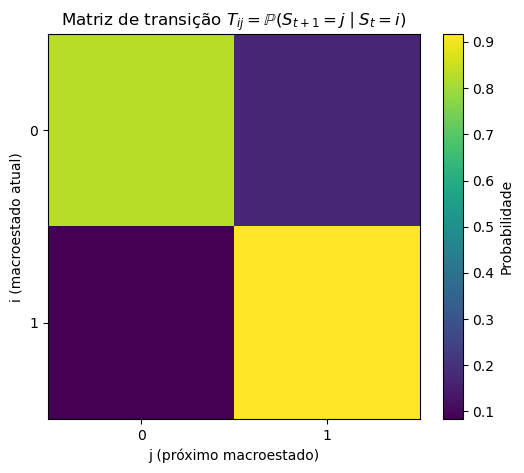

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(T.values, aspect="auto")

ax.set_title(r"Matriz de transição $T_{ij}=\mathbb{P}(S_{t+1}=j\mid S_t=i)$")
ax.set_xlabel("j (próximo macroestado)")
ax.set_ylabel("i (macroestado atual)")
ax.set_xticks(range(K))
ax.set_yticks(range(K))

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probabilidade")

plt.show()

### **7.3 Interpretação física da matriz de transição**

A matriz de transição fornece uma interpretação clara da dinâmica temporal entre os dois regimes sísmicos identificados.

O elemento diagonal $T_{11}$ mostra que o **cluster 1**, associado a janelas com **maior taxa sísmica**, **maior liberação de energia** e **maior dispersão espacial da atividade**, apresenta **alta persistência temporal**. Uma vez que o sistema entra nesse regime ativo, a probabilidade de permanecer nele na janela subsequente é elevada, o que o caracteriza como o **regime dominante** da dinâmica observada nessa configuração.

Em contraste, o elemento $T_{00}$ indica que o **cluster 0**, associado a um regime de **menor atividade sísmica**, **menor energia liberada** e **maior concentração espacial**, possui **menor estabilidade temporal**. Embora esse regime basal esteja presente em parte significativa da série, sua permanência média é menor, o que indica maior propensão a transições em direção ao regime ativo.

Os termos fora da diagonal, $T_{01}$ e $T_{10}$, reforçam essa assimetria dinâmica. Em particular, a probabilidade $T_{01}$ mostra que episódios de menor atividade tendem a ser interrompidos com frequência pela entrada em janelas mais energéticas, enquanto o valor relativamente menor de $T_{10}$ indica que a transição inversa, do regime ativo para o basal, é menos frequente. Essa assimetria sugere que, na escala temporal considerada, a dinâmica sísmica da região favorece a persistência de estados mais ativos.

Em conjunto, esses resultados indicam que a sismicidade analisada pode ser descrita, nessa configuração, como uma dinâmica efetiva de dois estados, na qual o regime ativo atua como o macroestado mais persistente, enquanto o regime basal emerge como um estado relativamente menos estável e mais suscetível a perturbações.

## **8. Dinâmica dos macroestados: CNN 1D**

- **Preprocessing**

In [30]:
drop_cols = ["cluster", "window_start", "window_end", "window_label"]

df_seq = (
    features_df
    .dropna(subset=["window_start", "cluster"])
    .sort_values("window_start")
    .reset_index(drop=True)
    .copy()
)
# Encode classes/labels
le = LabelEncoder() 
y = le.fit_transform(features_df["cluster"]) # Encoded target [0, 0, 1, 2, ...]

print("Classes:", le.classes_)

feature_cols = [c for c in df_seq.columns if c not in drop_cols]
X_tab = df_seq[feature_cols].copy()  # (n_windows or n_steps, n_features)
y_tab = df_seq["cluster"].astype(int).copy() # Vector of labels per window
t_tab = df_seq["window_start"].copy() # Timestamp per window

Classes: [0 1]


In [31]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_imp = imputer.fit_transform(X_tab)
X_scaled = scaler.fit_transform(X_imp)

- **Create temporal sequence**

In [32]:
def make_temporal_sequences(X, y, times, seq_len=8, horizon=1):
    X_seq, y_seq, t_seq = [], [], []

    n_steps = len(X)
    for end_idx in range(seq_len - 1, n_steps - horizon):
        start_idx = end_idx - seq_len + 1
        target_idx = end_idx + horizon # index for the next label (next cluster)

        X_seq.append(X[start_idx:end_idx + 1]) # Sequência de janelas passadas
        y_seq.append(y[target_idx])  # Próximo macroestado
        t_seq.append(times.iloc[target_idx]) # Timestamp of the next macrostate
    
    return np.array(X_seq), np.array(y_seq), np.array(t_seq)

In [33]:
seq_len = 8     # 12 janelas de 4h = 48h de contexto
horizon = 1      # prever o próximo macroestado

X_seq, y_seq, t_seq = make_temporal_sequences(
    X_scaled,
    y_tab.to_numpy(),
    t_tab,
    seq_len=seq_len,
    horizon=horizon
)

print(X_seq.shape, y_seq.shape)

(26384, 8, 38) (26384,)


- **Temporal splitting**

In [34]:
t_train = pd.Series(t_seq).quantile(0.6)
t_val   = pd.Series(t_seq).quantile(0.8)

train_mask = t_seq < t_train
val_mask   = (t_seq >= t_train) & (t_seq < t_val)
test_mask  = t_seq >= t_val

X_train, y_train = X_seq[train_mask], y_seq[train_mask]
X_val, y_val     = X_seq[val_mask], y_seq[val_mask]
X_test, y_test   = X_seq[test_mask], y_seq[test_mask]

print(X_train.shape, X_val.shape, X_test.shape)

(15830, 8, 38) (5277, 8, 38) (5277, 8, 38)


- **Classification metrics**

In [35]:
def evaluate_model(name, y_true, y_pred, y_prob=None, class_names=None):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(f"Accuracy   : {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1 macro   : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1 weighted: {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
    plt.title(f"Confusion matrix — {name}")
    plt.tight_layout()
    plt.show()

    if y_prob is not None:
        n_classes = len(np.unique(y_true))

        plt.figure(figsize=(7, 5))

        if n_classes == 2:
            # probabilidade da classe positiva
            pos_prob = y_prob[:, 1] if y_prob.shape[1] == 2 else y_prob.ravel()
            fpr, tpr, _ = roc_curve(y_true, pos_prob)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"Positive class (AUC={roc_auc:.2f})")

        else:
            y_bin = label_binarize(y_true, classes=np.arange(n_classes))
            for i, cls in enumerate(class_names):
                fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
                plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")

        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title(f"ROC curve — {name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

- **CNN 1D**

In [36]:
n_features = X_train.shape[2]
n_classes = len(np.unique(y_seq))

model = keras.Sequential([
    keras.layers.Input(shape=(seq_len, n_features)),
    keras.layers.Conv1D(filters=128, kernel_size=3, activation="relu"),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(n_classes, activation="softmax")
])


model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

E0000 00:00:1773599290.225327    8282 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 128)         │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,914 (73.88 KB)

 Trainable params: 18,914 (73.88 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7963 - loss: 0.4469 - val_accuracy: 0.8403 - val_loss: 0.3640
Epoch 2/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - accuracy: 0.8503 - loss: 0.3636 - val_accuracy: 0.8452 - val_loss: 0.3555
Epoch 3/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - accuracy: 0.8582 - loss: 0.3404 - val_accuracy: 0.8556 - val_loss: 0.3334
Epoch 4/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step - accuracy: 0.8672 - loss: 0.3247 - val_accuracy: 0.8522 - val_loss: 0.3390
Epoch 5/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - accuracy: 0.8702 - loss: 0.3119 - val_accuracy: 0.8399 - val_loss: 0.3675
Epoch 6/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.8733 - loss: 0.3011 - val_accuracy: 0.8357 - val_loss: 0.3638
Epoch 7/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.8794 - loss: 0.2935 - val_accuracy: 0.8418 - val_loss: 0.3596
Epoch 8/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - accuracy: 0.8826 - loss: 0.2

165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step

  CNN-1D
Accuracy   : 0.8094
F1 macro   : 0.7659
F1 weighted: 0.8092

              precision    recall  f1-score   support

           0       0.67      0.66      0.67      1506
           1       0.87      0.87      0.87      3771

    accuracy                           0.81      5277
   macro avg       0.77      0.77      0.77      5277
weighted avg       0.81      0.81      0.81      5277



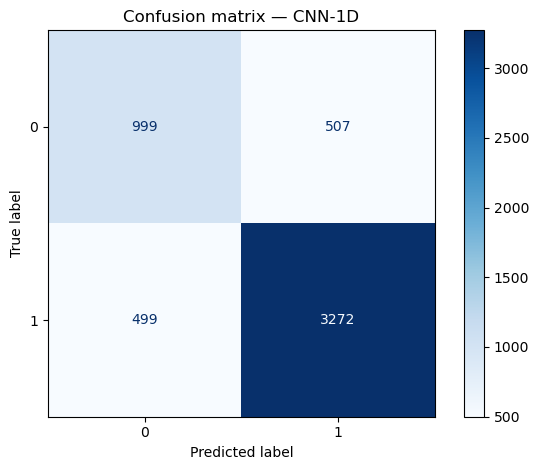

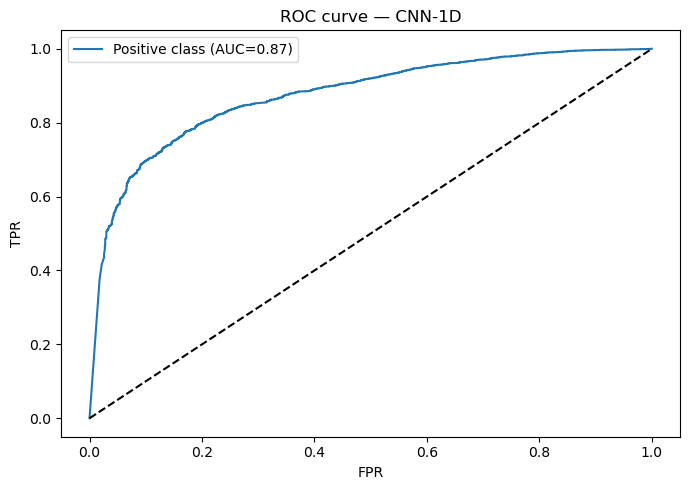

In [38]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

class_names = [str(c) for c in np.unique(y_test)]

evaluate_model(
    "CNN-1D",
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    class_names=class_names
)

A CNN não prova sozinha a existência física de dois regimes, mas fornece evidência adicional de que a coarse-graining + clusterização capturou uma estrutura temporal real e preditiva.

## **8. Coerência espacial dos regimes dinâmicos**

### **8.1 Reconstrução espacial dos clusters sobre eventos reais**

Essa etapa não constitui uma validação estatística formal do modelo, mas uma checagem qualitativa de interpretabilidade física. Ao projetar os rótulos dos clusters sobre os eventos reais, verificamos se os regimes identificados no espaço de features preservam coerência quando observados diretamente no domínio espaço-temporal da sismicidade. No caso presente, essa inspeção reforça a interpretação de dois regimes distintos: um regime mais basal, associado a menor atividade e maior concentração espacial, e um regime mais ativo, associado a maior taxa sísmica, maior liberação de energia e maior dispersão geográfica.

In [39]:
from src.spatial_validation.plots import (
    make_time_gate,
    prepare_spatial_frames,
    load_plates_geojson,
    plot_clusters_with_plates,
)

YEAR, MONTH, N_MONTHS = 2025, 6, 6
minmag = 4.5

start, end = make_time_gate(year=YEAR, month=MONTH, n_months=N_MONTHS)
tmp, ev = prepare_spatial_frames(features_df=features_df, df=df, start=start, end=end, minmag=minmag)
plates_geojson = load_plates_geojson()

fig = plot_clusters_with_plates(tmp=tmp, ev=ev, plates_geojson=plates_geojson, start=start, end=end, minmag=minmag)
fig.show()

# salva figura html interativa
reports_dir = Path("../reports")
reports_dir.mkdir(exist_ok=True)

outpath = reports_dir / "clusters_map_mag4p5_2026_06_6m.html"
fig.write_html(outpath)


Os pontos pequenos representam os eventos sísmicos reais ($M \ge 4.5$), coloridos de acordo com o regime dinâmico (cluster) identificado pelo modelo de clusterização na janela temporal correspondente. As linhas pretas indicam as fronteiras de placas tectônicas.

### **8.2 Interpretação quantitativa da dispersão espacial dos regimes**

,count,mean_km,median_km,std_km,q25_km,q75_km,p90_km
cluster,,,,,,,
0,1167,1235.252099,767.726517,1738.608111,322.040353,1523.816650,2367.664046
1,3205,1644.104751,1073.481092,1908.015425,455.507967,2097.458495,3539.302199


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Centroid distance to nearest plate boundary (km)'}, xlabel='Cluster', ylabel='Distance to plate (km)'>)

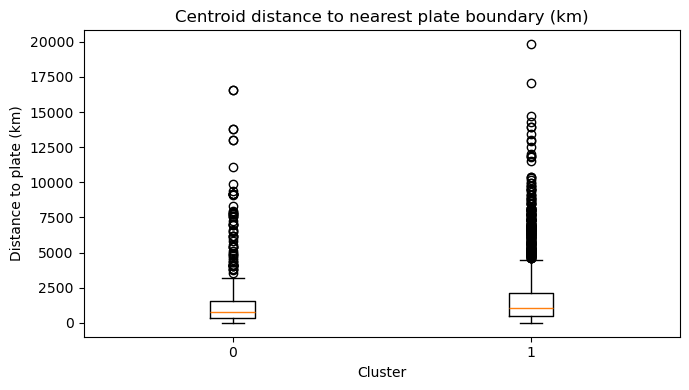

In [40]:
tmp_dist = add_plate_distance_column(tmp, plates_geojson)
summary = summarize_plate_distance_by_cluster(tmp_dist)
display(summary)

plot_distance_boxplot(tmp_dist)


Os box-plots da distância entre os centróides das janelas e a fronteira de placa tectônica mais próxima mostram, à primeira vista, um resultado aparentemente contraintuitivo: o **Cluster 1 (Ativo/Crítico)** apresenta mediana e dispersão de distâncias maiores do que o **Cluster 0 (Basal/Calmo)**.

Esse resultado, no entanto, **não deve ser interpretado** como evidência de que o regime ativo seja predominantemente intraplaca. A distância considerada aqui é calculada a partir do **centróide geométrico da janela**, e não da posição individual dos eventos. Assim, janelas associadas ao **Cluster 0**, marcadas por atividade mais localizada, tendem a gerar centróides próximos de uma única borda tectônica ativa. Já janelas associadas ao **Cluster 1**, caracterizadas por maior taxa sísmica, maior energia liberada e maior dispersão espacial, podem reunir eventos quase simultâneos em diferentes segmentos tectônicos do globo.

Nesses casos, o centróide funciona como um centro geométrico efetivo do conjunto de eventos e pode ser deslocado para regiões oceânicas ou continentais afastadas das bordas de placa, aumentando artificialmente sua distância à fronteira tectônica mais próxima. Portanto, o aumento dessa métrica no **Cluster 1** deve ser entendido como uma consequência natural de sua **maior extensão espacial**, em consonância com os altos valores de `spread` observados nesse regime.

## **9. Perspectivas futuras e próximos passos**

A validação física e espacial do modelo de regimes dinâmicos abre caminho para investigações mais profundas sobre a estabilidade e a universalidade da abordagem proposta. Os próximos passos concentram-se em três eixos principais:

**1. Análise de Sensibilidade e Robustez Paramétrica**:
O estudo atual fixou a janela temporal ($\Delta t$), levando a uma análise primária. Investigações futuras devem submeter o modelo a testes de estresse variando a granulação temporal. O objetivo é verificar a invariância dos clusters identificados e da Matriz de Transição. Um regime físico robusto deve persistir independentemente de pequenas variações nos hiperparâmetros de extração, garantindo que os estados (Basal vs. Crítico) não sejam artefatos da discretização escolhida.

**2.Formalização como Sistema de Dois Níveis (TLS)**: Dada a clara distinção binária observada (Repouso vs. Atividade), propõe-se aprofundar o tratamento teórico do fenômeno como um Sistema de Dois Níveis (Two-Level System), análogo a modelos de física estatística. Isso envolve analisar a distribuição dos tempos de residência (waiting times) em cada estado. Verificar se esses tempos seguem uma distribuição exponencial (processo de Poisson) ou leis de potência permitirá classificar a sismicidade global não apenas como uma cadeia de Markov, mas como um sistema físico com memória ou criticalidade auto-organizada (SOC).

**3. Generalização para Outros Sistemas Estocásticos**: A metodologia desenvolvida (Feature Engineering temporal seguida de Clustering não supervisionado e validação via Markov)  possui potencial de aplicação universal em séries temporais não estacionárias. Pretende-se expandir a aplicação para domínios fora da sismologia, tais como:

- **Climatologia:** Identificação de regimes de estabilidade vs. eventos extremos em dados de precipitação e temperatura.

- **Ativos Financeiros:** Detecção de regimes de volatilidade em ativos de alta frequência, onde "calmaria" e "crise" alternam-se de forma estocástica similar aos terremotos.

Essa agenda de pesquisa visa transformar o modelo atual de uma ferramenta de diagnóstico sísmico para um framework generalizável de detecção de fases em sistemas complexos